<a href="https://colab.research.google.com/github/facundoVega/ProcesamientoDelHabla/blob/main/VEGA_FACUNDO_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping


**Horacio Facundo Vega**



## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
! pip install requests beautifulsoup4

- En esta primera parte de la consigna se procede a realizar el webscrapping del sitio  que contiene nuestro texto a analizar.
- Como se trata de un sitio web estático, basta con obtener el contenido crudo del sitio e iterar sobre sus elementos para obtener el texto a analizar.

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
#Obtengo la pagina web.
discurso_url = "https://www.iade.org.ar/noticias/discurso-de-pepe-mujica-en-rio20"
respuesta = requests.get(discurso_url)
respuesta.raise_for_status()

In [ ]:
#Convierto el HTML del sitio en un objeto python navegable
sopa = BeautifulSoup(respuesta.text, 'html.parser')

In [ ]:
#Obtengo el texto especifico que voy a analizar desde el sitio web
contenido = sopa.find('div', class_="field-content")

if contenido is None:
    raise ValueError("No se encontro el div .field-content")

parrafos = contenido.find_all("p", recursive=False)

seleccionados = parrafos[2:-1]

textos = [p.get_text(strip=True) for p in seleccionados]


In [ ]:
#Compruebo que el contenido del texto es el discurso concretamente
for text in textos:
  print(text)

Autoridades presentes de todas la latitudes y organismos, muchas gracias. Muchas gracias al pueblo de Brasil y a su Sra. Presidenta, Dilma Rousseff. Muchas gracias a la buena fe que, seguramente, han manifestado todos los oradores que me precedieron. Expresamos la íntima voluntad como gobernantes de acompañar todos los acuerdos que, esta, nuestra pobre humanidad, pueda suscribir.
Sin embargo, permítasenos hacer algunas preguntas en voz alta. Toda la tarde se ha hablado del desarrollo sustentable. De sacar las inmensas masas de la pobreza.
¿Qué es lo que aletea en nuestras cabezas? ¿El modelo de desarrollo y de consumo, que es el actual de las sociedades ricas? Me hago esta pregunta: ¿qué le pasaría a este planeta si los hindúes tuvieran la misma proporción de autos por familia que tienen los alemanes?
¿Cuánto oxígeno nos quedaría para poder respirar? Más claro: ¿Tiene el mundo hoy los elementos materiales como para hacer posible que 7 mil u 8 mil millones de personas puedan tener el mi

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Para mostrar las stopwords del texto se utiliza la libreria NLTK de python que ya trae una lista de stop words del idioma Español.

Para mostrar las Stop words se realizan las siguientes tareas en orden:


1.   Se quita los signos de puntuación en el texto.
2.   Se hace una tokenización simple mediante el metodo "split"
3.   Finalmente utilizando una colección de tipo "set" se procede a almacenar las Stop words encontradas en el texto.




In [ ]:
#Elimino los signos de puntuación
import string

def quitar_puntuacion(texto):
  return [
      ''.join(c for c in parrafo.lower() if c not in string.punctuation)
        for parrafo in texto
  ]

print(quitar_puntuacion(textos))


['autoridades presentes de todas la latitudes y organismos muchas gracias muchas gracias al pueblo de brasil y a su sra presidenta dilma rousseff muchas gracias a la buena fe que seguramente han manifestado todos los oradores que me precedieron expresamos la íntima voluntad como gobernantes de acompañar todos los acuerdos que esta nuestra pobre humanidad pueda suscribir', 'sin embargo permítasenos hacer algunas preguntas en voz alta toda la tarde se ha hablado del desarrollo sustentable de sacar las inmensas masas de la pobreza', '¿qué es lo que aletea en nuestras cabezas ¿el modelo de desarrollo y de consumo que es el actual de las sociedades ricas me hago esta pregunta ¿qué le pasaría a este planeta si los hindúes tuvieran la misma proporción de autos por familia que tienen los alemanes', '¿cuánto oxígeno nos quedaría para poder respirar más claro ¿tiene el mundo hoy los elementos materiales como para hacer posible que 7 mil u 8 mil millones de personas puedan tener el mismo grado de

In [ ]:
#Utilizo la libreria nltk que ya tiene una lista de stopwords en español.
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


#Lista de stopwords en español
stopwords_es = set(stopwords.words('spanish'))

#Utilizaremos una lista de tipo set para guardas los valores encontrados no duplicados.
stopwords_encontradas = set()

palabras = " ".join(quitar_puntuacion(textos)).lower().split()
stopwords_encontradas.update(
      palabra for palabra in palabras
      if palabra in stopwords_es
  )

print("stopwords encontradas:")
print(sorted(stopwords_encontradas))


stopwords encontradas:
['a', 'al', 'algunas', 'antes', 'como', 'contra', 'cuando', 'de', 'del', 'el', 'en', 'es', 'esas', 'ese', 'eso', 'esta', 'estamos', 'estas', 'este', 'esto', 'estos', 'estoy', 'está', 'están', 'fue', 'ha', 'han', 'hay', 'hemos', 'la', 'las', 'le', 'lo', 'los', 'me', 'mi', 'mis', 'mucho', 'muy', 'más', 'nada', 'ni', 'no', 'nos', 'nosotros', 'nuestra', 'nuestras', 'o', 'otra', 'otro', 'para', 'pero', 'poco', 'por', 'porque', 'que', 'qué', 'se', 'sin', 'son', 'su', 'tanto', 'tendremos', 'tenemos', 'tiene', 'tienen', 'todo', 'todos', 'tuvieran', 'un', 'una', 'uno', 'unos', 'y', 'yo']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

En esta primera parte de la consigna se procede a:

*   Crear un método para quitar caracteres extraños. En base al Regex utilizado
todo lo que no sea un caracter alfa-numérico o un espacio, sera eliminado.
*   También se define un método para eliminar las stop words en español.
*   El regex utilizado se extrajo de un apunte sobre vectorización impartido en la clase 2 de esta meteria.
   






In [ ]:
#Defino un método para quitar caracteres extraños
import re

def eliminar_caracteres_raros(texto):
  return re.sub(r'[^\w\s]', '', texto)

In [ ]:
#Defino un método para eliminar las stop words

def eliminar_stop_words(texto):
  palabras = texto.lower().split()
  return [p for p in palabras if p not in stopwords_es]


In [ ]:
#Limpio el texto de stopwords y carácteres extraños
texto_completo = " ".join(textos)
texto_sin_caracteres_raros = eliminar_caracteres_raros(texto_completo)
palabras_procesadas = eliminar_stop_words(texto_sin_caracteres_raros)

print(palabras_procesadas)

['autoridades', 'presentes', 'todas', 'latitudes', 'organismos', 'muchas', 'gracias', 'muchas', 'gracias', 'pueblo', 'brasil', 'sra', 'presidenta', 'dilma', 'rousseff', 'muchas', 'gracias', 'buena', 'fe', 'seguramente', 'manifestado', 'oradores', 'precedieron', 'expresamos', 'íntima', 'voluntad', 'gobernantes', 'acompañar', 'acuerdos', 'pobre', 'humanidad', 'pueda', 'suscribir', 'embargo', 'permítasenos', 'hacer', 'preguntas', 'voz', 'alta', 'toda', 'tarde', 'hablado', 'desarrollo', 'sustentable', 'sacar', 'inmensas', 'masas', 'pobreza', 'aletea', 'cabezas', 'modelo', 'desarrollo', 'consumo', 'actual', 'sociedades', 'ricas', 'hago', 'pregunta', 'pasaría', 'planeta', 'si', 'hindúes', 'misma', 'proporción', 'autos', 'familia', 'alemanes', 'cuánto', 'oxígeno', 'quedaría', 'poder', 'respirar', 'claro', 'mundo', 'hoy', 'elementos', 'materiales', 'hacer', 'posible', '7', 'mil', 'u', '8', 'mil', 'millones', 'personas', 'puedan', 'tener', 'mismo', 'grado', 'consumo', 'despilfarro', 'opulentas'

En esta segunda parte de la consigna se procede a generar la nube de palabras utilizando las palabras del texto que ya fueron procesadas y la libreria "***wordcloud***" y ***MatPlotLib***.

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
texto_wordcloud = " ".join(palabras_procesadas)


# Crear un objeto WordCloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="#1e1e1e",
    colormap="viridis",
    max_words=150,
    contour_width=2,
    contour_color="white"
    ).generate(texto_wordcloud)


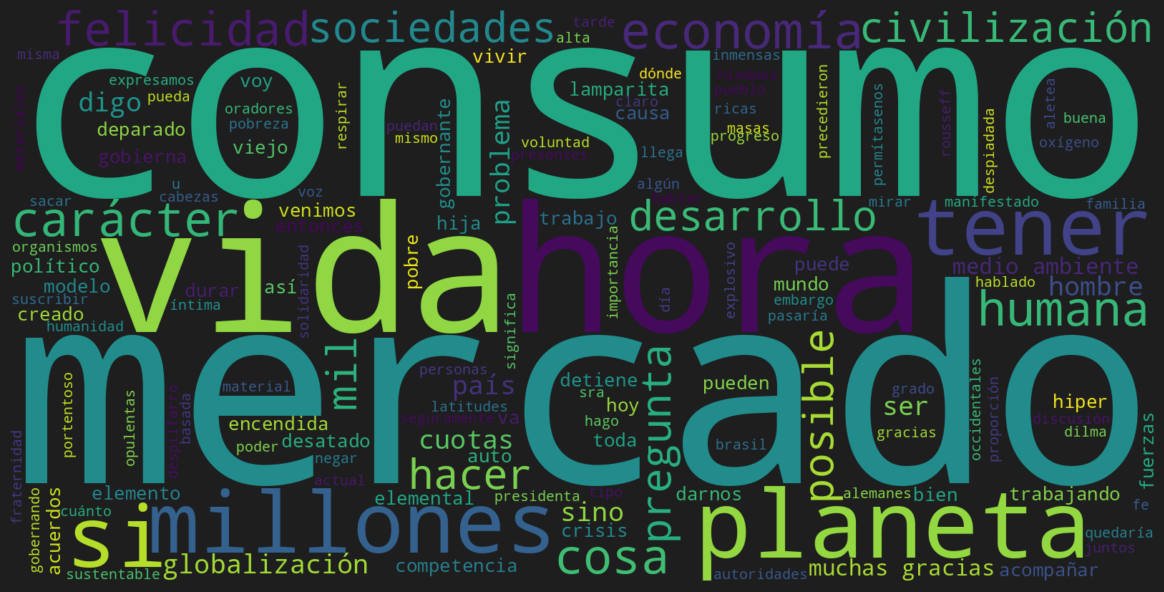

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(12, 6), facecolor="#1e1e1e")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=1)
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


Para esta parte del trabajo utilizaremos la libreria Spacy, ya que la misma nos brinda la posibilidad de utilizar lematización a la hora de Tokenizar, aportando la capacidad de entender el contexto gramatical.

In [ ]:
#Instalo el modelo en español de Spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 29.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#Transformo el contenido del sitio web de una lista de parrafos a un string.
texto_total = " ".join(textos)
print(texto_total)

Autoridades presentes de todas la latitudes y organismos, muchas gracias. Muchas gracias al pueblo de Brasil y a su Sra. Presidenta, Dilma Rousseff. Muchas gracias a la buena fe que, seguramente, han manifestado todos los oradores que me precedieron. Expresamos la íntima voluntad como gobernantes de acompañar todos los acuerdos que, esta, nuestra pobre humanidad, pueda suscribir. Sin embargo, permítasenos hacer algunas preguntas en voz alta. Toda la tarde se ha hablado del desarrollo sustentable. De sacar las inmensas masas de la pobreza. ¿Qué es lo que aletea en nuestras cabezas? ¿El modelo de desarrollo y de consumo, que es el actual de las sociedades ricas? Me hago esta pregunta: ¿qué le pasaría a este planeta si los hindúes tuvieran la misma proporción de autos por familia que tienen los alemanes? ¿Cuánto oxígeno nos quedaría para poder respirar? Más claro: ¿Tiene el mundo hoy los elementos materiales como para hacer posible que 7 mil u 8 mil millones de personas puedan tener el mi

In [ ]:
import spacy
# Cargo el modelo de Spacy en español
nlp = spacy.load('es_core_news_sm')

In [ ]:
#Creo un elemento doc para que spacy analize el texto palabra por palabra y poder procesarlo
doc = nlp(texto_total)

Preproceso y limpio el texto. Se van a eliminar los signos de puntuación, espacios, y las stop words. También se hara una lematización de los terminos del documento.

In [ ]:

oraciones_limpias = [
    [
      token.lemma_.lower()
      for token in sent
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
    ]
    for sent in doc.sents
]

print(f"Cantidad de oraciones: ", len(oraciones_limpias))
print(oraciones_limpias)

Cantidad de oraciones:  62
[['autoridad', 'presente', 'latitud', 'organismo', 'gracia'], ['gracia', 'pueblo', 'brasil', 'sra.', 'presidenta', 'dilma', 'rousseff'], ['gracias', 'fe', 'seguramente', 'manifestar', 'orador', 'preceder'], ['expresar', 'íntimo', 'voluntad', 'gobernante', 'acompañar', 'acuerdo', 'pobre', 'humanidad', 'suscribir'], ['permítasenos', 'pregunta', 'voz', 'alto'], ['hablar', 'desarrollo', 'sustentable'], ['sacar', 'inmenso', 'masa', 'pobreza'], ['aletear', 'cabeza'], ['modelo', 'desarrollo', 'consumo', 'actual', 'sociedad', 'rico'], ['pregunta', 'pasar', 'planeta', 'hindúes', 'tener', 'proporción', 'auto', 'familia', 'alemán'], ['oxígeno', 'quedar', 'respirar'], ['mundo', 'elemento', 'material', '7', 'mil', '8', 'mil', 'millón', 'persona', 'poder', 'grado', 'consumo', 'despilfarro', 'opulenta', 'sociedad', 'occidental'], [], ['tener', 'dar yo', 'tipo', 'discusión'], ['crear', 'civilización', 'hija', 'mercado', 'hija', 'competencia', 'deparar', 'progreso', 'material

Ahora que tenemos los tokens ya depurados por oración en una lista, procedo a generar la matriz documento vocabulario. Para este trabajo utilizaré la libreria scikit learn que a partir de ajustar un modelo prodremos generar un vector de frecuencia sencillo que nos de esa matriz documento vocabulario.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizador = CountVectorizer(
    analyzer = lambda document: document,
    token_pattern = None
)

matriz_frecuencias = vectorizador.fit_transform(oraciones_limpias)

vocabulario = vectorizador.get_feature_names_out()

documento_vocabulario  = pd.DataFrame(
    matriz_frecuencias.toarray(),
    columns=vocabulario,
    index=[f"Oracion {i + 1}" for i in range(len(oraciones_limpias))]
)

display(documento_vocabulario)


,-porque,10,100,1000,13,3,6,7,8,90%,acompañar,acordar,actual,acuerdo,agredir,agresión,agua,alemán,aletear,alto,ambiente,amigo,amor,aparecer,aprovechable,atraso,auto,autoridad,aymaras-,basado,brasil,cabeza,cantidad,carne,carácter,causa,caverna,civilización,clave,colosal,comida,compañero,competencia,conseguir,consumir,consumo,contrario,corto,cosa,crear,crisis,cuidado,cultura,cultural,cuota,círculo,dar yo,decir,definir,definitiva,deparar,desafío,desarrollar yo,desarrollo,desatar,desear,despiadado,despilfarro,destino,detener,dilma,discusión,dotado,durar,ecológico,economía,elemental,elemento,eléctrico,empezar,encendido,epicúreo,escapar,esfuerzo,estancamiento,estupendo,evento,explosivo,exportador,expresar,familia,fantasma,favor,fe,felicidad,feliz,forma,fraternidad,fuerza,general,generar,globalización,gobernado,gobernante,gobernar,gracia,gracias,grado,habitante,hablar,hija,hijo,hindúes,hiper,hombre,hora,humanidad,humano,humilde,importancia,importante,indefinidamente,indicar,infinitamente,inmenso,junto,lamparita,latitud,llamar,llegar,luchar,lácteo,magnitud,manifestar,masa,material,mejor,mercado,mil,millón,mirar,modelo,montar,monumento,moto,motor,mundo,natural,necesitar,negar,nosotros-,occidental,opulenta,orador,organismo,oveja,oxígeno,pagar,paralizar,pasar,país,penillanura,pensador,pensar,pequeño,permítasenos,persona,pertenecer,planeta,plantearno,plus,pobre,pobreza,poder,político,portentoso,preceder,precisamente,pregunta,presente,presidenta,problema,progreso,proporción,pueblo,quedar,rechinar,recordar,recurso,relación,respirar,reumático,revisar,rico,rousseff,sacar,saludar,seguir,seguramente,significar,sociedad,solidaridad,sostener,sra.,suscribir,sustentable,séneca,tener,territorio,tesoro,tierra,tipo,trabajador,trabajar,trabajo,tírelo,vaca,valer,vender,venir,vicioso,vida,viejo,vivir,voluntad,volver,voz,yo-,época,íntimo,úselo
Oracion 1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Oracion 2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Oracion 3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Oracion 4,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
Oracion 5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
print(f"La longitud del vocabulario es:", len(vocabulario))

La longitud del vocabulario es: 231



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

Previo a este paso se construyó una matriz documento-vocaluario utilizando las frecuencias de aparición de cada término en cada documento(oración). Ahora se aplica la técnica de TF-IDF para ponderar la relevancia de cada término dentro del corpus, obteniendo la matriz TF-IDF.

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [ ]:
#Aplico TF-IDF
from sklearn.feature_extraction.text import TfidfTransformer

transformador = TfidfTransformer()

matriz_tfidf = transformador.fit_transform(matriz_frecuencias)

df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns = vocabulario,
    index=documento_vocabulario.index
)

display(df_tfidf)

num_documentos, tam_vocabulario = df_tfidf.shape
print(f"Numero de documentos del corpus: ", num_documentos )
print(f"Longitud del vocabulario: ",tam_vocabulario )

,-porque,10,100,1000,13,3,6,7,8,90%,acompañar,acordar,actual,acuerdo,agredir,agresión,agua,alemán,aletear,alto,ambiente,amigo,amor,aparecer,aprovechable,atraso,auto,autoridad,aymaras-,basado,brasil,cabeza,cantidad,carne,carácter,causa,caverna,civilización,clave,colosal,comida,compañero,competencia,conseguir,consumir,consumo,contrario,corto,cosa,crear,crisis,cuidado,cultura,cultural,cuota,círculo,dar yo,decir,definir,definitiva,deparar,desafío,desarrollar yo,desarrollo,desatar,desear,despiadado,despilfarro,destino,detener,dilma,discusión,dotado,durar,ecológico,economía,elemental,elemento,eléctrico,empezar,encendido,epicúreo,escapar,esfuerzo,estancamiento,estupendo,evento,explosivo,exportador,expresar,familia,fantasma,favor,fe,felicidad,feliz,forma,fraternidad,fuerza,general,generar,globalización,gobernado,gobernante,gobernar,gracia,gracias,grado,habitante,hablar,hija,hijo,hindúes,hiper,hombre,hora,humanidad,humano,humilde,importancia,importante,indefinidamente,indicar,infinitamente,inmenso,junto,lamparita,latitud,llamar,llegar,luchar,lácteo,magnitud,manifestar,masa,material,mejor,mercado,mil,millón,mirar,modelo,montar,monumento,moto,motor,mundo,natural,necesitar,negar,nosotros-,occidental,opulenta,orador,organismo,oveja,oxígeno,pagar,paralizar,pasar,país,penillanura,pensador,pensar,pequeño,permítasenos,persona,pertenecer,planeta,plantearno,plus,pobre,pobreza,poder,político,portentoso,preceder,precisamente,pregunta,presente,presidenta,problema,progreso,proporción,pueblo,quedar,rechinar,recordar,recurso,relación,respirar,reumático,revisar,rico,rousseff,sacar,saludar,seguir,seguramente,significar,sociedad,solidaridad,sostener,sra.,suscribir,sustentable,séneca,tener,territorio,tesoro,tierra,tipo,trabajador,trabajar,trabajo,tírelo,vaca,valer,vender,venir,vicioso,vida,viejo,vivir,voluntad,volver,voz,yo-,época,íntimo,úselo
Oracion 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.455201,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.413725,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.455201,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.455201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.455201,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
Oracion 2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.382749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.382749,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.347875,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.382749,0.0,0.0,0.0,0.382749,0.0,0.0,0.000000

Numero de documentos del corpus:  62
Longitud del vocabulario:  231


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

La matriz resultante es una matriz documento-vocabulario ponderada mediante TF-IDF.

*   Cada fila representa un documento del corpus. En este trabajo, cada documento
corresponde a una oración obtenida del texto original.

*  Cada columna representa un término único lematizado del vocabulario extraído tras el preprocesamiento del texto.

*  Cada celda contiene el peso TF-IDF del término en el documento correspondiente, indicando la importancia relativa de dicho termino en el corpus

*  Es importante destacar que la matriz generada por Scikit-Learn se normaliza por defecto, por eso los valores de cada celda estan entre 0 y 1.

De manera mas puntual podemos ver que términos como "aletear" y "acompañar" tienen un TF-IDF elevado (0.707) lo que indica que son altamente representativos de los documentos en los que aparecen. Esto ocurre por que dichos términos tiene una frecuencia relativamente alta en ese documento y una frecuencia baja en el resto del corpus, permitiendo distinguir mejor el contenido de esa oración respecto a las demas.
Mientras que términos como "pregunta" o "presente" presentan un peso TF-IDF de 0.41, indicando una relevancia moderadada dentro del documento. Esto sugiere que la palabra contribuye a caracterizar la oración aunque existen otros términos con mayor capacidad discriminativa dentro del corpus.

# Conclusiones

A partir de este trabajo práctico pude entender mejor los desafíos que presenta a veces el web scrapping. Al depender de un sitio web externo y en mi caso puntal de la estructura HTML del mismo, (ya que se trata de un sitio web estático) entendí que tanto se puede  dificultar   la obtencion automatizada de la información del sitio.
También me pareció muy interesante y potente "***wordcloud***" como técnica de visualización, ya que de manera muy simple y tan solo un golpe de vista se puede analizar los términos de un texto, en cuanto a su frecuencia.

Por ultimo, tanto a la hora del preprocesamiento, como al momento de generar la matriz documento-vocabulario y la ponderación TF-IDF pude entender de primera mano lo mucho que se agiliza el desarrollo de estos  elementos a partir de la utilización de librerias. Pude notar esta diferencia ya que en algunos notebooks compartidos por la docente en clases anteriores todos estos procesos se hicieron de forma más manual utilizando numpy, lo cual fue muy útil para entender como funcionan estas librerias internamente, cada concepto impartido como asi también para entender mejor todo lo que podemos abstraernos utilizando los modulos correctos.

**Fuentes del Código:**

---
Todo el código de este TP fue creado a partir de las colab de ejemplo  compartidas por la docente en las clases anteriores, y algunos prompts en github copilot. Por eso es que cada proceso y tarea que componen este TP es estrictamente validado ya sea con un print o un display para corroborar que la salida de cada bloque de código es la esperada. Cada linea de código en este TP fue minuciosamente comprendida, depurada y validada por el autor de este colab.


